# Revenue Forecast (Customer Spend Prediction)
สร้างโมเดล Regression เพื่อพยากรณ์ยอดใช้จ่ายของลูกค้า (Monetary)
โดยใช้ปัจจัยเรื่องความถี่ในการซื้อ (Frequency), ระยะเวลาที่ห่างหายไป (Recency) และกลุ่มลูกค้า (Segment) มาเป็นตัวแปรต้น

# Import & Load

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
import os

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

COLORS   = ['#534AB7', '#0F6E56', '#BA7517', '#993C1D']
N_MONTHS = 6

os.makedirs('data/processed', exist_ok=True)
os.makedirs('diagrams', exist_ok=True)

rfm = pd.read_csv('data/processed/rfm_clustered.csv')

print("=" * 50)
print("  NOTEBOOK 03 — Ridge Regression")
print("=" * 50)
print(f"\n✅ โหลดข้อมูลสำเร็จ: {rfm.shape}")
print(rfm.head())

  NOTEBOOK 03 — Ridge Regression

✅ โหลดข้อมูลสำเร็จ: (500, 5)
  customer_id  recency  frequency  monetary   segment
0       C0001      112          1    252.55       New
1       C0002        3          6   3157.74  Champion
2       C0003       24         10   5297.44     Loyal
3       C0004      141          1     15.85       New
4       C0005       25          8   4229.73     Loyal


# 1. สร้าง Target Variable: spend_next_30d


──────────────────────────────────────────────────
  SECTION 1 — สร้าง Target Variable
──────────────────────────────────────────────────

Target Variable: spend_next_30d
count      500.00
mean      1107.99
std       1732.16
min          0.00
25%         41.28
50%        375.56
75%       1109.06
max      10456.90
Name: spend_next_30d, dtype: float64


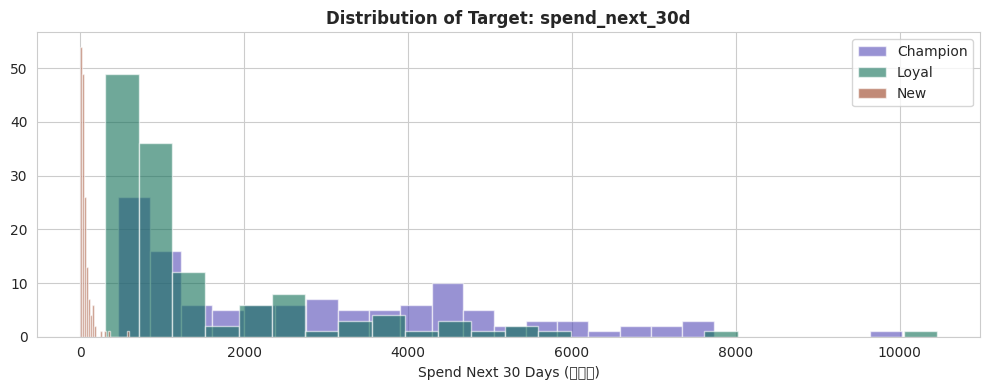

✅ Chart บันทึกแล้ว


In [21]:
print("\n" + "─" * 50)
print("  SECTION 1 — สร้าง Target Variable")
print("─" * 50)

np.random.seed(42)

base_spend = rfm['monetary'] / N_MONTHS
noise      = np.random.normal(loc=1.0, scale=0.20, size=len(rfm))
noise      = np.clip(noise, 0.5, 1.8)  # กันค่าสุดโต่ง

rfm['spend_next_30d'] = (base_spend * noise).round(2)

print("\nTarget Variable: spend_next_30d")
print(rfm['spend_next_30d'].describe().round(2))

# Distribution แยก segment
seg_color_map = {
    'Champion': COLORS[0], 'Loyal'  : COLORS[1],
    'At-Risk' : COLORS[2], 'New'    : COLORS[3]
}
fig, ax = plt.subplots(figsize=(10, 4))
for seg, grp in rfm.groupby('segment'):
    color = seg_color_map.get(seg, '#888')
    ax.hist(grp['spend_next_30d'], bins=25,
            alpha=0.6, label=seg, color=color)
ax.set_title('Distribution of Target: spend_next_30d', fontweight='bold')
ax.set_xlabel('Spend Next 30 Days (บาท)')
ax.legend()
plt.tight_layout()
plt.savefig('diagrams/03_target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Chart บันทึกแล้ว")

# 2. Feature Engineering

In [22]:
print("\n" + "─" * 50)
print("  SECTION 2 — Feature Engineering")
print("─" * 50)

# Encode segment เป็น dummy variables
rfm_model = pd.get_dummies(rfm, columns=['segment'],
                            prefix='seg', drop_first=False)

# Interaction feature: frequency × monetary (proxy CLV)
rfm_model['freq_x_monetary'] = rfm['frequency'] * rfm['monetary']

seg_cols = [c for c in rfm_model.columns if c.startswith('seg_')]
FEATURES = ['recency', 'frequency', 'monetary', 'freq_x_monetary'] + seg_cols
TARGET   = 'spend_next_30d'

X = rfm_model[FEATURES]
y = rfm_model[TARGET]

print(f"\nFeatures ({len(FEATURES)} ตัว):")
for f in FEATURES:
    print(f"  - {f}")
print(f"\nTarget : {TARGET}")
print(f"Shape  : X={X.shape}, y={y.shape}")


──────────────────────────────────────────────────
  SECTION 2 — Feature Engineering
──────────────────────────────────────────────────

Features (7 ตัว):
  - recency
  - frequency
  - monetary
  - freq_x_monetary
  - seg_Champion
  - seg_Loyal
  - seg_New

Target : spend_next_30d
Shape  : X=(500, 7), y=(500,)


# 3. Train Ridge Regression

In [23]:
print("\n" + "─" * 50)
print("  SECTION 3 — Train Ridge Regression")
print("─" * 50)

# Train/Test split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Train Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)

y_pred = ridge.predict(X_test_s)
y_pred = np.maximum(y_pred, 0)  # ยอดซื้อติดลบไม่มีความหมาย

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "=" * 45)
print("  RIDGE REGRESSION — Test Results")
print("=" * 45)
print(f"  R²   : {r2:.4f}  (1.0 = perfect)")
print(f"  MAE  : {mae:.2f} บาท")
print(f"  RMSE : {rmse:.2f} บาท")
print("=" * 45)


──────────────────────────────────────────────────
  SECTION 3 — Train Ridge Regression
──────────────────────────────────────────────────

  RIDGE REGRESSION — Test Results
  R²   : 0.9650  (1.0 = perfect)
  MAE  : 134.31 บาท
  RMSE : 307.37 บาท


# 4. เปรียบเทียบ OLS vs Ridge vs Lasso

In [24]:
print("\n" + "─" * 50)
print("  SECTION 4 — Model Comparison")
print("─" * 50)

models = {
    'OLS (Linear)': LinearRegression(),
    'Ridge (L2)'  : Ridge(alpha=1.0),
    'Lasso (L1)'  : Lasso(alpha=0.1),
}
print(f"\n{'Model':<20} {'R²':>8} {'MAE':>10} {'RMSE':>10}")
print("─" * 52)
for name, m in models.items():
    m.fit(X_train_s, y_train)
    yp   = np.maximum(m.predict(X_test_s), 0)
    r2_  = r2_score(y_test, yp)
    mae_ = mean_absolute_error(y_test, yp)
    rm_  = np.sqrt(mean_squared_error(y_test, yp))
    tag  = " ← เลือกใช้" if 'Ridge' in name else ''
    print(f"{name:<20} {r2_:>8.4f} {mae_:>10.2f} {rm_:>10.2f}{tag}")


──────────────────────────────────────────────────
  SECTION 4 — Model Comparison
──────────────────────────────────────────────────

Model                      R²        MAE       RMSE
────────────────────────────────────────────────────
OLS (Linear)           0.9677     134.95     295.38
Ridge (L2)             0.9650     134.31     307.37 ← เลือกใช้
Lasso (L1)             0.9676     134.67     295.65


# 5. Visualize Model Performance


──────────────────────────────────────────────────
  SECTION 5 — Model Performance Charts
──────────────────────────────────────────────────


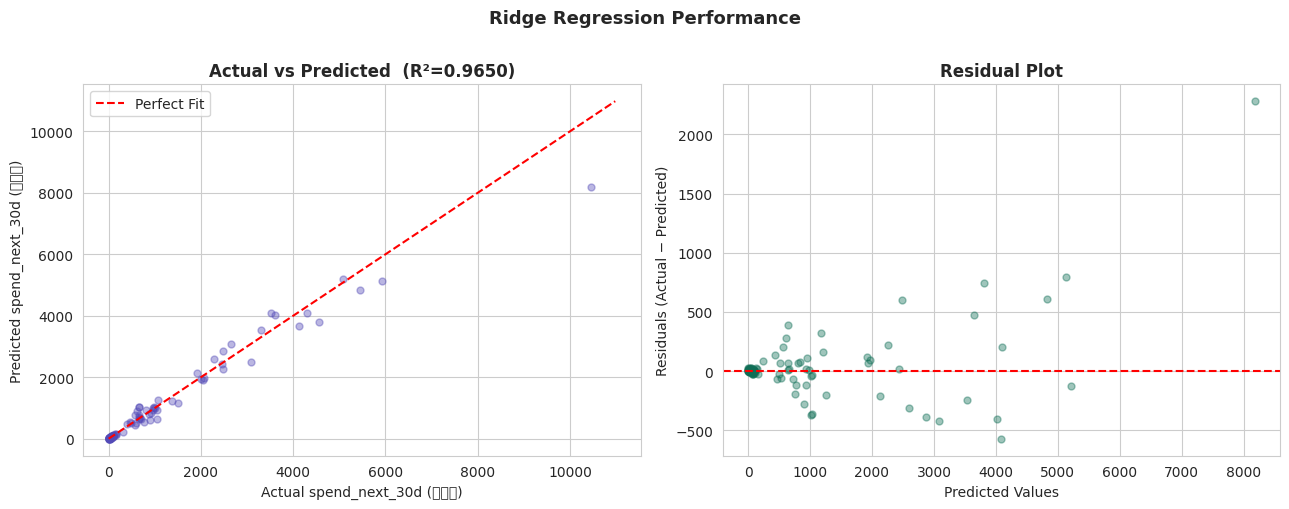


💡 Residual Plot ที่ดี: จุดกระจายรอบ y=0 แบบสุ่ม ไม่มี pattern


In [25]:
print("\n" + "─" * 50)
print("  SECTION 5 — Model Performance Charts")
print("─" * 50)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, color=COLORS[0], s=25)
lim = max(y_test.max(), y_pred.max()) * 1.05
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect Fit')
axes[0].set_xlabel('Actual spend_next_30d (บาท)')
axes[0].set_ylabel('Predicted spend_next_30d (บาท)')
axes[0].set_title(f'Actual vs Predicted  (R²={r2:.4f})', fontweight='bold')
axes[0].legend()

# Residual Plot
residuals = y_test.values - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color=COLORS[1], s=25)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals (Actual − Predicted)')
axes[1].set_title('Residual Plot', fontweight='bold')

plt.suptitle('Ridge Regression Performance',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('diagrams/03_regression_performance.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("\n💡 Residual Plot ที่ดี: จุดกระจายรอบ y=0 แบบสุ่ม ไม่มี pattern")

# 6. Feature Importance (Coefficients)


──────────────────────────────────────────────────
  SECTION 6 — Feature Coefficients
──────────────────────────────────────────────────

Top features ที่ส่งผลต่อ predicted spend:
        feature  coefficient
       monetary  1682.577032
      frequency    90.244719
   seg_Champion   -50.948052
freq_x_monetary   -21.972727
        recency     6.916472
      seg_Loyal    -2.757607
        seg_New    -1.647928


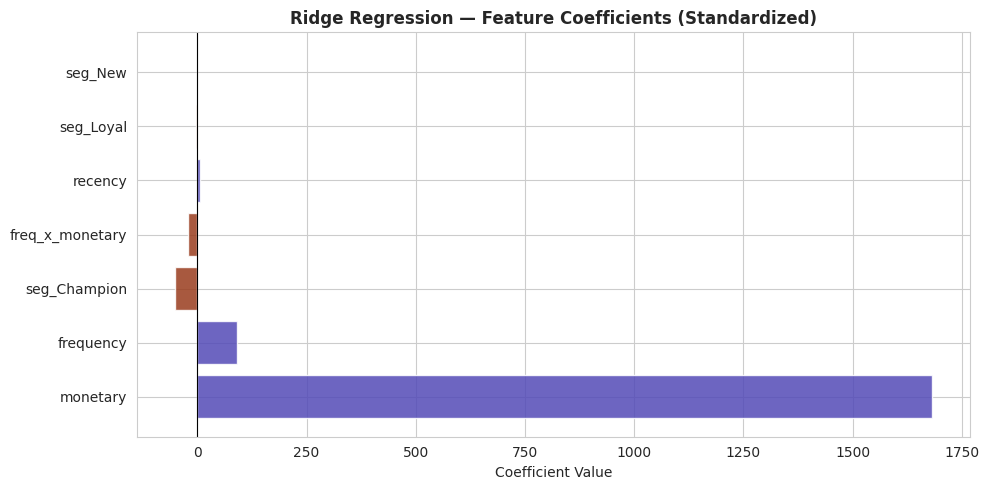


💡 Positive = เพิ่ม predicted spend | Negative = ลด predicted spend


In [26]:
print("\n" + "─" * 50)
print("  SECTION 6 — Feature Coefficients")
print("─" * 50)

coef_df = pd.DataFrame({
    'feature'    : FEATURES,
    'coefficient': ridge.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("\nTop features ที่ส่งผลต่อ predicted spend:")
print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors  = [COLORS[0] if c > 0 else COLORS[3]
           for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'],
        color=colors, alpha=0.85)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Ridge Regression — Feature Coefficients (Standardized)',
             fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('diagrams/03_feature_coefficients.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("\n💡 Positive = เพิ่ม predicted spend | Negative = ลด predicted spend")

# 7. Cross Validation

In [27]:
print("\n" + "─" * 50)
print("  SECTION 7 — 5-Fold Cross Validation")
print("─" * 50)

X_all_s  = scaler.fit_transform(X)
cv_scores = cross_val_score(Ridge(alpha=1.0), X_all_s, y,
                             cv=5, scoring='r2')

print("\n5-Fold Cross Validation — R² Scores:")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"\n  Mean R² : {cv_scores.mean():.4f}")
print(f"  Std R²  : {cv_scores.std():.4f}  ← ยิ่งต่ำ = ยิ่ง stable")
print("\n💡 Std ต่ำ = model ไม่ overfit กับ training fold ใด fold หนึ่ง")


──────────────────────────────────────────────────
  SECTION 7 — 5-Fold Cross Validation
──────────────────────────────────────────────────

5-Fold Cross Validation — R² Scores:
  Fold 1: 0.9564
  Fold 2: 0.9532
  Fold 3: 0.9480
  Fold 4: 0.9539
  Fold 5: 0.9478

  Mean R² : 0.9519
  Std R²  : 0.0034  ← ยิ่งต่ำ = ยิ่ง stable

💡 Std ต่ำ = model ไม่ overfit กับ training fold ใด fold หนึ่ง


# 8. Predict ทุกคน + Business Insight


──────────────────────────────────────────────────
  SECTION 8 — Predict ทุกคน
──────────────────────────────────────────────────

Spend Threshold (40th pct): ฿118.46

ลูกค้าที่ควรได้รับโปร (needs_promotion=1):
segment
Champion    0
Loyal       0
New         1

รวม: 3 คน จาก 500 คน (0.6%)


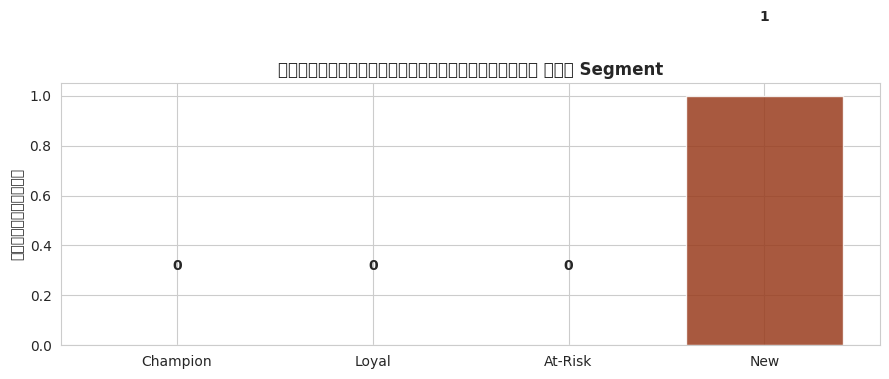

In [28]:
print("\n" + "─" * 50)
print("  SECTION 8 — Predict ทุกคน")
print("─" * 50)

X_all_s = scaler.transform(X)
rfm['predicted_spend_30d'] = np.maximum(
    ridge.predict(X_all_s), 0
).round(2)

# ลูกค้าที่ควรได้โปร = predicted_spend ต่ำ แต่ monetary เคยสูง
SPEND_THRESHOLD = rfm['predicted_spend_30d'].quantile(0.40)

rfm['needs_promotion'] = (
    (rfm['predicted_spend_30d'] < SPEND_THRESHOLD) &
    (rfm['monetary'] > rfm['monetary'].quantile(0.40))
).astype(int)

print(f"\nSpend Threshold (40th pct): ฿{SPEND_THRESHOLD:.2f}")
print(f"\nลูกค้าที่ควรได้รับโปร (needs_promotion=1):")
print(rfm.groupby('segment')['needs_promotion'].sum().to_string())
total_need = rfm['needs_promotion'].sum()
print(f"\nรวม: {total_need} คน จาก {len(rfm)} คน "
      f"({rfm['needs_promotion'].mean()*100:.1f}%)")

# Chart
fig, ax = plt.subplots(figsize=(9, 4))
seg_order = ['Champion', 'Loyal', 'At-Risk', 'New']
need_counts = rfm.groupby('segment')['needs_promotion'].sum()
vals   = [need_counts.get(s, 0) for s in seg_order]
colors = ['#534AB7', '#0F6E56', '#BA7517', '#993C1D']
bars   = ax.bar(seg_order, vals, color=colors, alpha=0.85, edgecolor='white')
ax.set_title('จำนวนลูกค้าที่ควรได้รับโปร ต่อ Segment', fontweight='bold')
ax.set_ylabel('จำนวนลูกค้า')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3,
            str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('diagrams/03_needs_promotion.png', dpi=120, bbox_inches='tight')
plt.show()

# Save Output

In [29]:
print("\n" + "─" * 50)
print("  SECTION 9 — Save Output")
print("─" * 50)

out_cols = ['customer_id', 'recency', 'frequency', 'monetary',
            'segment', 'predicted_spend_30d', 'needs_promotion']
rfm[out_cols].to_csv('data/processed/rfm_with_forecast.csv', index=False)

print(f"\n✅ บันทึก rfm_with_forecast.csv")
print(f"   {len(rfm)} customers × {len(out_cols)} columns")
print(f"   Columns: {out_cols}")
print("\n→ ต่อไป: 04_xgboost.py (Layer 3)")
print("=" * 50)


──────────────────────────────────────────────────
  SECTION 9 — Save Output
──────────────────────────────────────────────────

✅ บันทึก rfm_with_forecast.csv
   500 customers × 7 columns
   Columns: ['customer_id', 'recency', 'frequency', 'monetary', 'segment', 'predicted_spend_30d', 'needs_promotion']

→ ต่อไป: 04_xgboost.py (Layer 3)
